# Regression pipeline for predicting Oral Temperature from Infrared Thermography data

0. Import all necessary modules

In [170]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

1. Load the dataset from the excel sheet. The excel sheet has 4 sheets corresponding to 4 different trial of the experiment in a 10 minutes interval. Each trial is a `pandas.Dataframe` , and the variable `df_trials -> [pandas.Dataframe]` is a 4 length list storing each trial. We observe that the main header is in the row 3.

In [96]:
df=[pd.read_excel('../datasets/ICI.xlsx',sheet_name='Round 1',header=2),
     pd.read_excel('../datasets/ICI.xlsx',sheet_name='Round 2',header=2),
     pd.read_excel('../datasets/ICI.xlsx',sheet_name='Round 3',header=2),
     pd.read_excel('../datasets/ICI.xlsx',sheet_name='Round 4',header=2)]
df[0].head(10)

,SubjectID,T_offset1,Max1R13_1,Max1L13_1,aveAllR13_1,aveAllL13_1,T_RC1,T_RC_Dry1,T_RC_Wet1,T_RC_Max1,...,aveOralM,Gender,Age,Ethnicity,T_atm,Humidity,Distance,Cosmetics,Time,Date
0,161117-1,-0.27,34.94,35.48,34.05,34.74,34.92,34.92,34.71,34.94,...,36.59,Male,41-50,White,24.0,28.0,0.8,NaN,12:43:46,2017-11-16
1,161117-2,-0.21,33.56,34.93,33.23,34.14,34.80,33.97,34.80,34.89,...,37.19,Female,31-40,Black or African-American,24.0,26.0,0.8,NaN,15:22:48,2017-11-16
2,161117-3,-0.28,35.91,35.60,35.46,34.71,35.83,35.83,35.50,35.91,...,37.34,Female,21-30,White,24.0,26.0,0.8,NaN,15:52:56,2017-11-16
3,161117-4,-0.32,35.25,35.46,33.78,33.88,35.24,35.20,35.22,35.25,...,37.09,Female,21-30,Black or African-American,24.0,27.0,0.8,NaN,16:07:53,2017-11-16
4,161117-5,-0.52,35.57,35.78,34.38,35.27,35.60,35.54,35.60,35.66,...,37.04,Male,18-20,White,24.0,27.0,0.8,NaN,16:28:06,2017-11-16
5,161117-6,-0.26,34.87,35.11,34.10,34.62,34.88,34.88,34.75,34.89,...,36.99,Female,21-30,White,24.0,26.0,0.8,NaN,16:43:28,2017-11-16
6,161118-1,-0.14,35.01,35.46,34.48,34.54,34.98,34.98,34.72,35.01,...,36.59,Male,21-30,White,24.0,31.0,0.8,NaN,12:11:01,2018-11-16
7,161118-2,-0.79,34.54,34.52,33.49,33.31,34.57,34.57,34.28,34.67,...,36.49,Female,18-20,White,25.0,30.0,0.8,NaN,12:40:41,2018-11-16
8,161118-3,-0.20,35.17,35.44,33.59,33.99,35.56,34.87,35.56,35.58,...,36.99,Female,18-20,White,25.0,30.0,0.8,NaN,14:27:47,2018-11-16
9,161118-4,-0.32,35.22,35.36,33.62,34.47,35.30,35.15,35.30,35.31,...,36.59,Female,18-20,Asian,25.0,30.0,0.8,NaN,14:44:13,2018-11-16


2. Rename the columns in all the dataframe to a more legible name.

In [99]:
base_mapping = {
    'T_offset': 'Calibration_Offset',
    'Max1R13_': 'Right_Inner_Eye_Max',
    'Max1L13_': 'Left_Inner_Eye_Max',
    'aveAllR13_': 'Right_Inner_Eye_Avg',
    'aveAllL13_': 'Left_Inner_Eye_Avg',
    'T_RC': 'Right_Eye_Avg',
    'T_RC_Dry': 'Right_Eye_Skin',
    'T_RC_Wet': 'Right_Tear_Duct',
    'T_RC_Max': 'Right_Eye_Max',
    'T_LC': 'Left_Eye_Avg',
    'T_LC_Dry': 'Left_Eye_Skin',
    'T_LC_Wet': 'Left_Tear_Duct',
    'T_LC_Max': 'Left_Eye_Max',
    'RCC': 'Right_Eye_Center',
    'LCC': 'Left_Eye_Center',
    'canthiMax': 'Hottest_Eye_Overall',
    'canthi4Max': 'Hottest_Eye_4Points',
    'T_FHCC': 'Forehead_Center',
    'T_FHRC': 'Forehead_Right',
    'T_FHLC': 'Forehead_Left',
    'T_FHBC': 'Forehead_Bottom',
    'T_FHTC': 'Forehead_Top',
    'T_FH_Max': 'Forehead_Overall_Max',
    'T_FHC_Max': 'Forehead_Center_Max',
    'T_Max': 'Face_Overall_Max',
    'T_OR': 'Mouth_Avg',
    'T_OR_Max': 'Mouth_Max'
}
full_mapping = {
    'SubjectID': 'Subject_ID',
    'aveOralF': 'True_Core_Temp_Fast',
    'aveOralM': 'True_Core_Temp_Slow',
    'T_atm': 'Room_Temperature',
    'Humidity': 'Room_Humidity',
    'Distance': 'Camera_Distance_m',
    'Cosmetics': 'Wearing_Makeup'
}
for old_base, new_base in base_mapping.items():
    for round_num in range(1, 5):
        old_col_name = f"{old_base}{round_num}" if not old_base.endswith('_') else f"{old_base}{round_num}"
        new_col_name = f"{new_base}_R{round_num}" 
        full_mapping[old_col_name] = new_col_name

for i in range(len(df)):
    df[i].rename(columns=full_mapping, inplace=True)
df[0].head()

,Subject_ID,Calibration_Offset_R1,Right_Inner_Eye_Max_R1,Left_Inner_Eye_Max_R1,Right_Inner_Eye_Avg_R1,Left_Inner_Eye_Avg_R1,Right_Eye_Avg_R1,Right_Eye_Skin_R1,Right_Tear_Duct_R1,Right_Eye_Max_R1,...,True_Core_Temp_Slow,Gender,Age,Ethnicity,Room_Temperature,Room_Humidity,Camera_Distance_m,Wearing_Makeup,Time,Date
0,161117-1,-0.27,34.94,35.48,34.05,34.74,34.92,34.92,34.71,34.94,...,36.59,Male,41-50,White,24.0,28.0,0.8,NaN,12:43:46,2017-11-16
1,161117-2,-0.21,33.56,34.93,33.23,34.14,34.80,33.97,34.80,34.89,...,37.19,Female,31-40,Black or African-American,24.0,26.0,0.8,NaN,15:22:48,2017-11-16
2,161117-3,-0.28,35.91,35.60,35.46,34.71,35.83,35.83,35.50,35.91,...,37.34,Female,21-30,White,24.0,26.0,0.8,NaN,15:52:56,2017-11-16
3,161117-4,-0.32,35.25,35.46,33.78,33.88,35.24,35.20,35.22,35.25,...,37.09,Female,21-30,Black or African-American,24.0,27.0,0.8,NaN,16:07:53,2017-11-16
4,161117-5,-0.52,35.57,35.78,34.38,35.27,35.60,35.54,35.60,35.66,...,37.04,Male,18-20,White,24.0,27.0,0.8,NaN,16:28:06,2017-11-16


3. List all the column names in the dataframe

In [100]:
print(df[0].columns.tolist())

['Subject_ID', 'Calibration_Offset_R1', 'Right_Inner_Eye_Max_R1', 'Left_Inner_Eye_Max_R1', 'Right_Inner_Eye_Avg_R1', 'Left_Inner_Eye_Avg_R1', 'Right_Eye_Avg_R1', 'Right_Eye_Skin_R1', 'Right_Tear_Duct_R1', 'Right_Eye_Max_R1', 'Left_Eye_Avg_R1', 'Left_Eye_Skin_R1', 'Left_Tear_Duct_R1', 'Left_Eye_Max_R1', 'Right_Eye_Center_R1', 'Left_Eye_Center_R1', 'Hottest_Eye_Overall_R1', 'Hottest_Eye_4Points_R1', 'Forehead_Center_R1', 'Forehead_Right_R1', 'Forehead_Left_R1', 'Forehead_Bottom_R1', 'Forehead_Top_R1', 'Forehead_Overall_Max_R1', 'Forehead_Center_Max_R1', 'Face_Overall_Max_R1', 'Mouth_Avg_R1', 'Mouth_Max_R1', 'True_Core_Temp_Fast', 'True_Core_Temp_Slow', 'Gender', 'Age', 'Ethnicity', 'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m', 'Wearing_Makeup', 'Time', 'Date']


4. Identify and print numerical column, categorical column (ordinal, nominal).

In [101]:
nominal_cols = ['Subject_ID', 'Gender', 'Ethnicity', 'Wearing_Makeup']
ordinal_cols = ['Age']
datetime_cols = ['Time', 'Date']
all_cols = df[0].columns.tolist()
exclude_cols = nominal_cols + ordinal_cols + datetime_cols
numerical_cols = [col for col in all_cols if col not in exclude_cols]
print(f" NOMINAL COLUMNS ({len(nominal_cols)})")
print(nominal_cols)

print(f"\nORDINAL COLUMNS ({len(ordinal_cols)})")
print(ordinal_cols)

print(f"\n NUMERICAL COLUMNS ({len(numerical_cols)})")
print(numerical_cols)

 NOMINAL COLUMNS (4)
['Subject_ID', 'Gender', 'Ethnicity', 'Wearing_Makeup']

ORDINAL COLUMNS (1)
['Age']

 NUMERICAL COLUMNS (32)
['Calibration_Offset_R1', 'Right_Inner_Eye_Max_R1', 'Left_Inner_Eye_Max_R1', 'Right_Inner_Eye_Avg_R1', 'Left_Inner_Eye_Avg_R1', 'Right_Eye_Avg_R1', 'Right_Eye_Skin_R1', 'Right_Tear_Duct_R1', 'Right_Eye_Max_R1', 'Left_Eye_Avg_R1', 'Left_Eye_Skin_R1', 'Left_Tear_Duct_R1', 'Left_Eye_Max_R1', 'Right_Eye_Center_R1', 'Left_Eye_Center_R1', 'Hottest_Eye_Overall_R1', 'Hottest_Eye_4Points_R1', 'Forehead_Center_R1', 'Forehead_Right_R1', 'Forehead_Left_R1', 'Forehead_Bottom_R1', 'Forehead_Top_R1', 'Forehead_Overall_Max_R1', 'Forehead_Center_Max_R1', 'Face_Overall_Max_R1', 'Mouth_Avg_R1', 'Mouth_Max_R1', 'True_Core_Temp_Fast', 'True_Core_Temp_Slow', 'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m']


Here we prematurelt drop NAs because I observe in the sheet that there are missing rows, which can be dropped without imputations

In [102]:
df[0].isna().sum()

Subject_ID                  0
Calibration_Offset_R1      54
Right_Inner_Eye_Max_R1     53
Left_Inner_Eye_Max_R1      53
Right_Inner_Eye_Avg_R1     53
Left_Inner_Eye_Avg_R1      53
Right_Eye_Avg_R1           54
Right_Eye_Skin_R1          54
Right_Tear_Duct_R1         54
Right_Eye_Max_R1           54
Left_Eye_Avg_R1            54
Left_Eye_Skin_R1           54
Left_Tear_Duct_R1          54
Left_Eye_Max_R1            54
Right_Eye_Center_R1        55
Left_Eye_Center_R1         55
Hottest_Eye_Overall_R1     54
Hottest_Eye_4Points_R1     55
Forehead_Center_R1         54
Forehead_Right_R1          54
Forehead_Left_R1           54
Forehead_Bottom_R1         54
Forehead_Top_R1            54
Forehead_Overall_Max_R1    54
Forehead_Center_Max_R1     54
Face_Overall_Max_R1        54
Mouth_Avg_R1               54
Mouth_Max_R1               54
True_Core_Temp_Fast         0
True_Core_Temp_Slow         0
Gender                      0
Age                         0
Ethnicity                   0
Room_Tempe

### Visualizations

We observe above that out of 1009 records, only around 50 is NA. which is like 0.2% of the data. So we shall drop it

In [103]:
for i in range(len(df)):
    df[i].dropna(inplace=True)

Count of Male vs Female

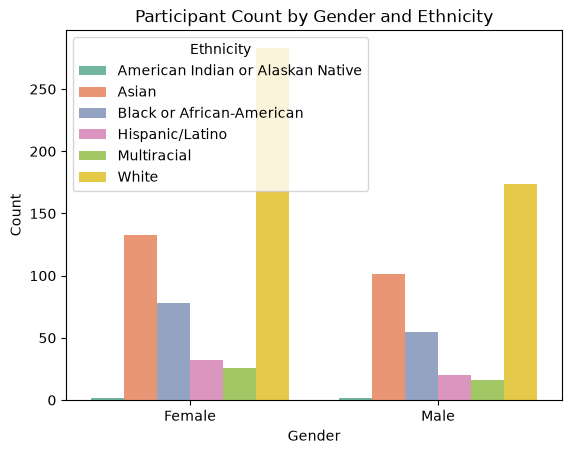

        Count
Gender       
Female    554
Male      368


In [113]:
male_female_counts = (
    df[0].loc[df[0]["Gender"].notna(), ["Gender", "Subject_ID"]]
    .groupby("Gender")
    .count()
    .rename(columns={"Subject_ID": "Count"})
)

gender_ethnicity_counts = (
    df[0][df[0]["Gender"].notnull() & df[0]["Ethnicity"].notnull()][["Subject_ID", "Gender", "Ethnicity"]]
    .groupby(["Gender", "Ethnicity"], as_index=False)
    .count()
    .rename(columns={"Subject_ID": "Count"})
)

sns.barplot(
    data=gender_ethnicity_counts,
    x="Gender",
    y="Count",
    hue="Ethnicity",
    palette="Set2"
)
plt.title("Participant Count by Gender and Ethnicity")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Ethnicity")
plt.show()

print(male_female_counts)

5. For the first trial, we will do the following visualizations

    - Scatterplot between all features in the dataset
    - Boxplot of all features to identify outliers
    - Historgram to identify the shape of all the features
    - Heatmap to idenitfy correlations between all the features.

a) Boxplot

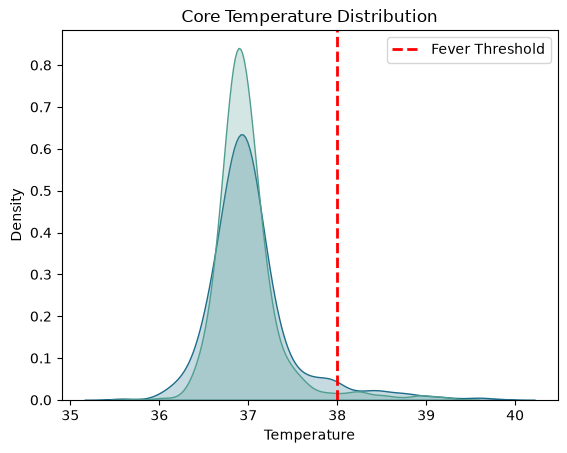

In [161]:
data = df[0].copy()
melted_data = data[['True_Core_Temp_Fast', 'True_Core_Temp_Slow']].melt(
    var_name='Sensor Type', 
    value_name='Temperature'
)

sns.kdeplot(
    data=melted_data, 
    x='Temperature', 
    hue='Sensor Type', 
    fill=True,
    palette='crest' 
)
fever_threshold = 38.0

plt.axvline(
    x=fever_threshold, 
    color='red',
    linestyle='--',        
    linewidth=2,           
    label='Fever Threshold' 
)

plt.title('Core Temperature Distribution')
plt.xlabel('Temperature')
plt.legend() 

plt.show()



C:\Users\navee\AppData\Local\Temp\ipykernel_15036\4013461676.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
C:\Users\navee\AppData\Local\Temp\ipykernel_15036\4013461676.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
C:\Users\navee\AppData\Local\Temp\ipykernel_15036\4013461676.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
C:\Users\navee\AppData\Lo

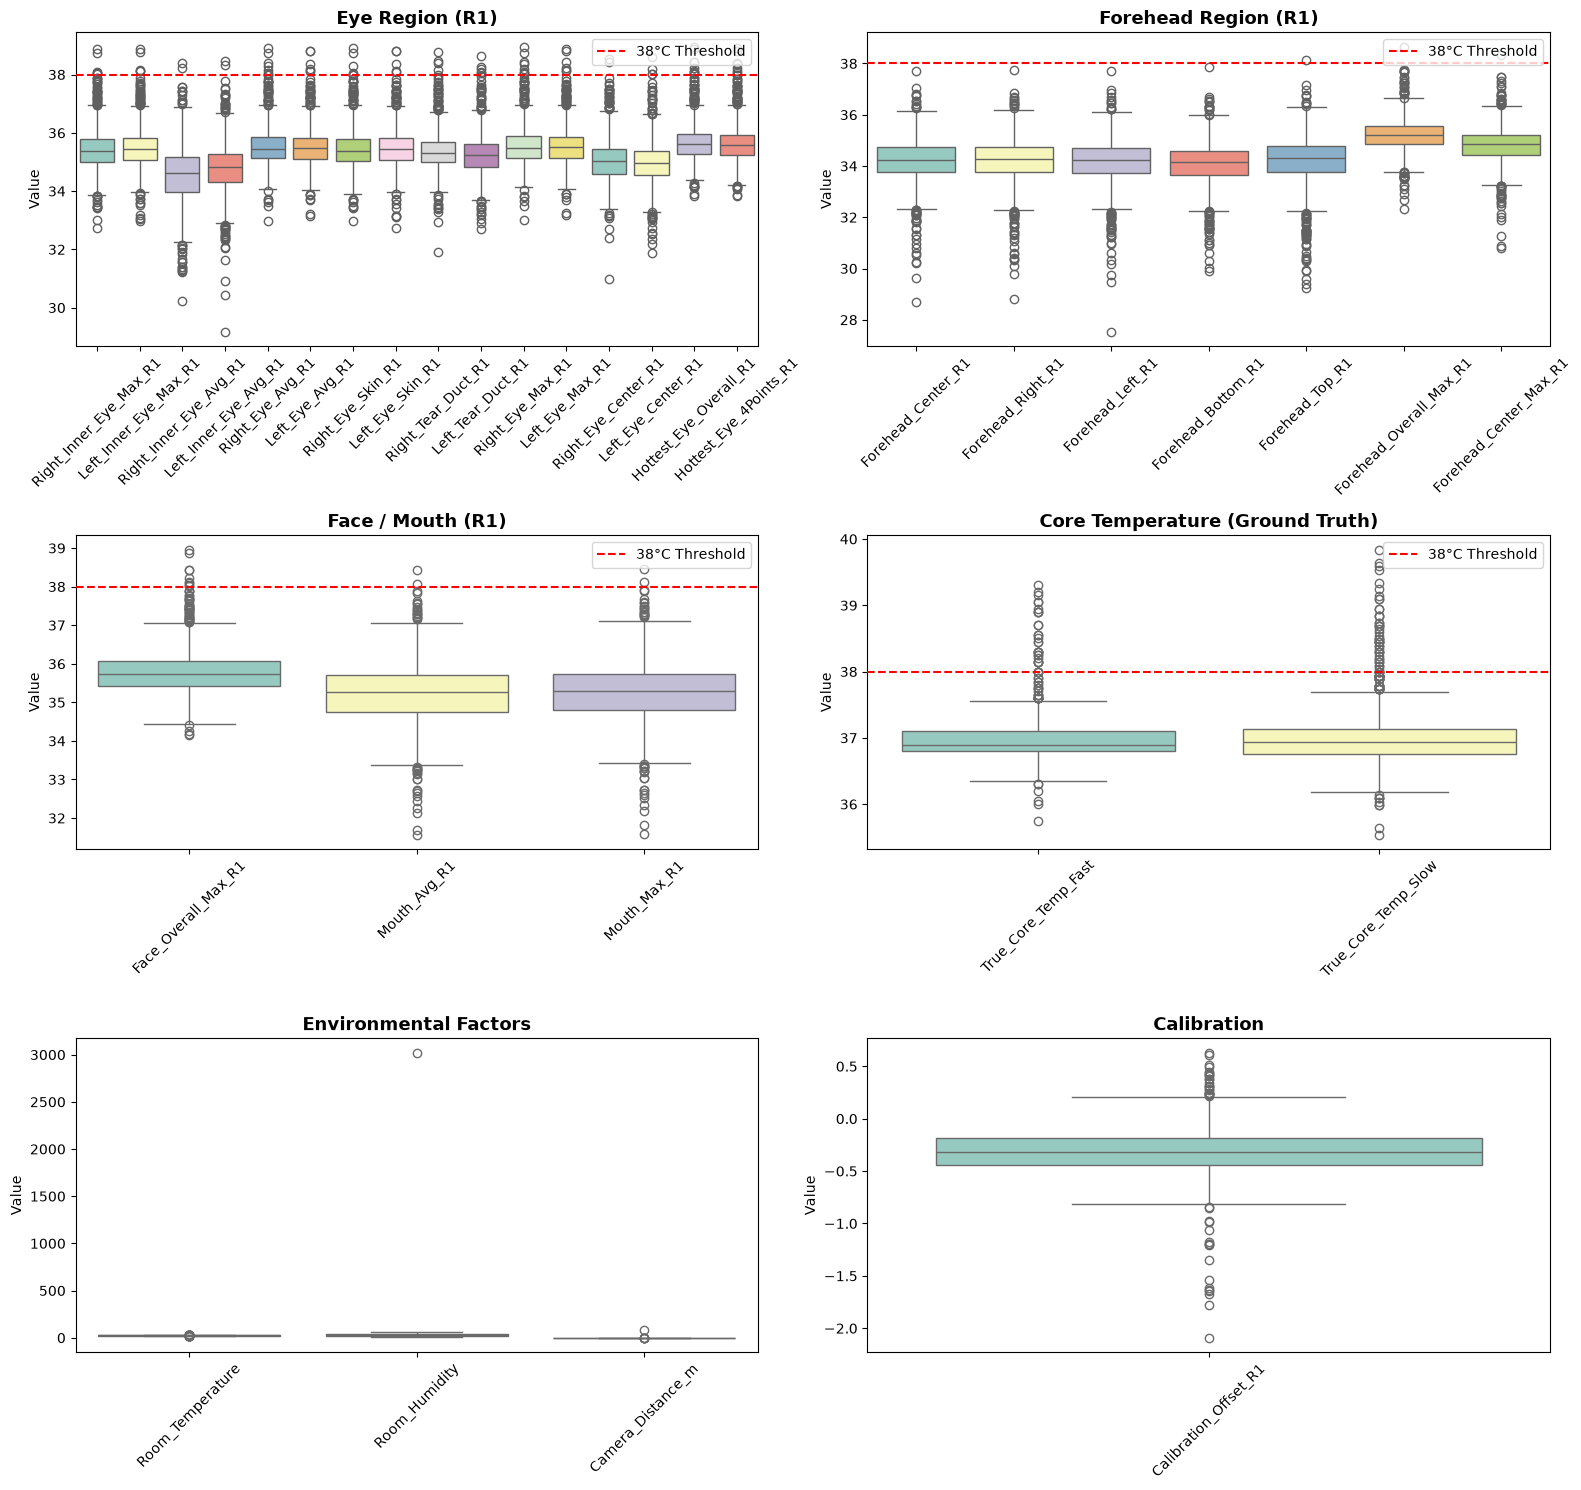

In [162]:
data = df[0].copy()

feature_groups = {
    "Eye Region (R1)": [
        'Right_Inner_Eye_Max_R1', 'Left_Inner_Eye_Max_R1',
        'Right_Inner_Eye_Avg_R1', 'Left_Inner_Eye_Avg_R1',
        'Right_Eye_Avg_R1', 'Left_Eye_Avg_R1',
        'Right_Eye_Skin_R1', 'Left_Eye_Skin_R1',
        'Right_Tear_Duct_R1', 'Left_Tear_Duct_R1',
        'Right_Eye_Max_R1', 'Left_Eye_Max_R1',
        'Right_Eye_Center_R1', 'Left_Eye_Center_R1',
        'Hottest_Eye_Overall_R1', 'Hottest_Eye_4Points_R1'
    ],
    "Forehead Region (R1)": [
        'Forehead_Center_R1', 'Forehead_Right_R1', 'Forehead_Left_R1',
        'Forehead_Bottom_R1', 'Forehead_Top_R1',
        'Forehead_Overall_Max_R1', 'Forehead_Center_Max_R1'
    ],
    "Face / Mouth (R1)": [
        'Face_Overall_Max_R1', 'Mouth_Avg_R1', 'Mouth_Max_R1'
    ],
    "Core Temperature (Ground Truth)": [
        'True_Core_Temp_Fast', 'True_Core_Temp_Slow'
    ],
    "Environmental Factors": [
        'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m'
    ],
    "Calibration": [
        'Calibration_Offset_R1'
    ]
}

n_groups = len(feature_groups)
n_cols = 2
n_rows = (n_groups + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for ax, (group_name, cols) in zip(axes, feature_groups.items()):
    melted = data[cols].melt(var_name="Feature", value_name="Value")
    sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
    if group_name not in ["Calibration", "Environmental Factors"]:
        ax.axhline(
            y=38.0, 
            color='red', 
            linestyle='--', 
            linewidth=1.5, 
            zorder=5, 
            label='38°C Threshold'
        )
        ax.legend(loc='upper right') 
    
    ax.set_title(group_name, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(feature_groups):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Remove outlier based on fever range

In [163]:
data = df[0].copy()

print(f"Records before filtering: {len(data)}")

data = data[data['True_Core_Temp_Fast'] <= 39.5]

print(f"Records after filtering: {len(data)}")

Records before filtering: 922
Records after filtering: 922


We remove an outlier in room_humidity.

In [164]:
data = data.copy()

env_cols = ['Room_Temperature', 'Room_Humidity', 'Camera_Distance_m']

print(f"Records before filtering: {len(data)}")

for col in env_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    before = len(data)
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
    after = len(data)
    
    print(f"{col}: removed {before - after} rows (bounds: {lower_bound:.2f} to {upper_bound:.2f})")

print(f"\nRecords after filtering: {len(data)}")

Records before filtering: 922
Room_Temperature: removed 61 rows (bounds: 21.45 to 26.65)
Room_Humidity: removed 1 rows (bounds: -9.50 to 61.70)
Camera_Distance_m: removed 6 rows (bounds: 0.45 to 0.85)

Records after filtering: 854


C:\Users\navee\AppData\Local\Temp\ipykernel_15036\555204.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
C:\Users\navee\AppData\Local\Temp\ipykernel_15036\555204.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
C:\Users\navee\AppData\Local\Temp\ipykernel_15036\555204.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
C:\Users\navee\AppData\Local\Temp\ipy

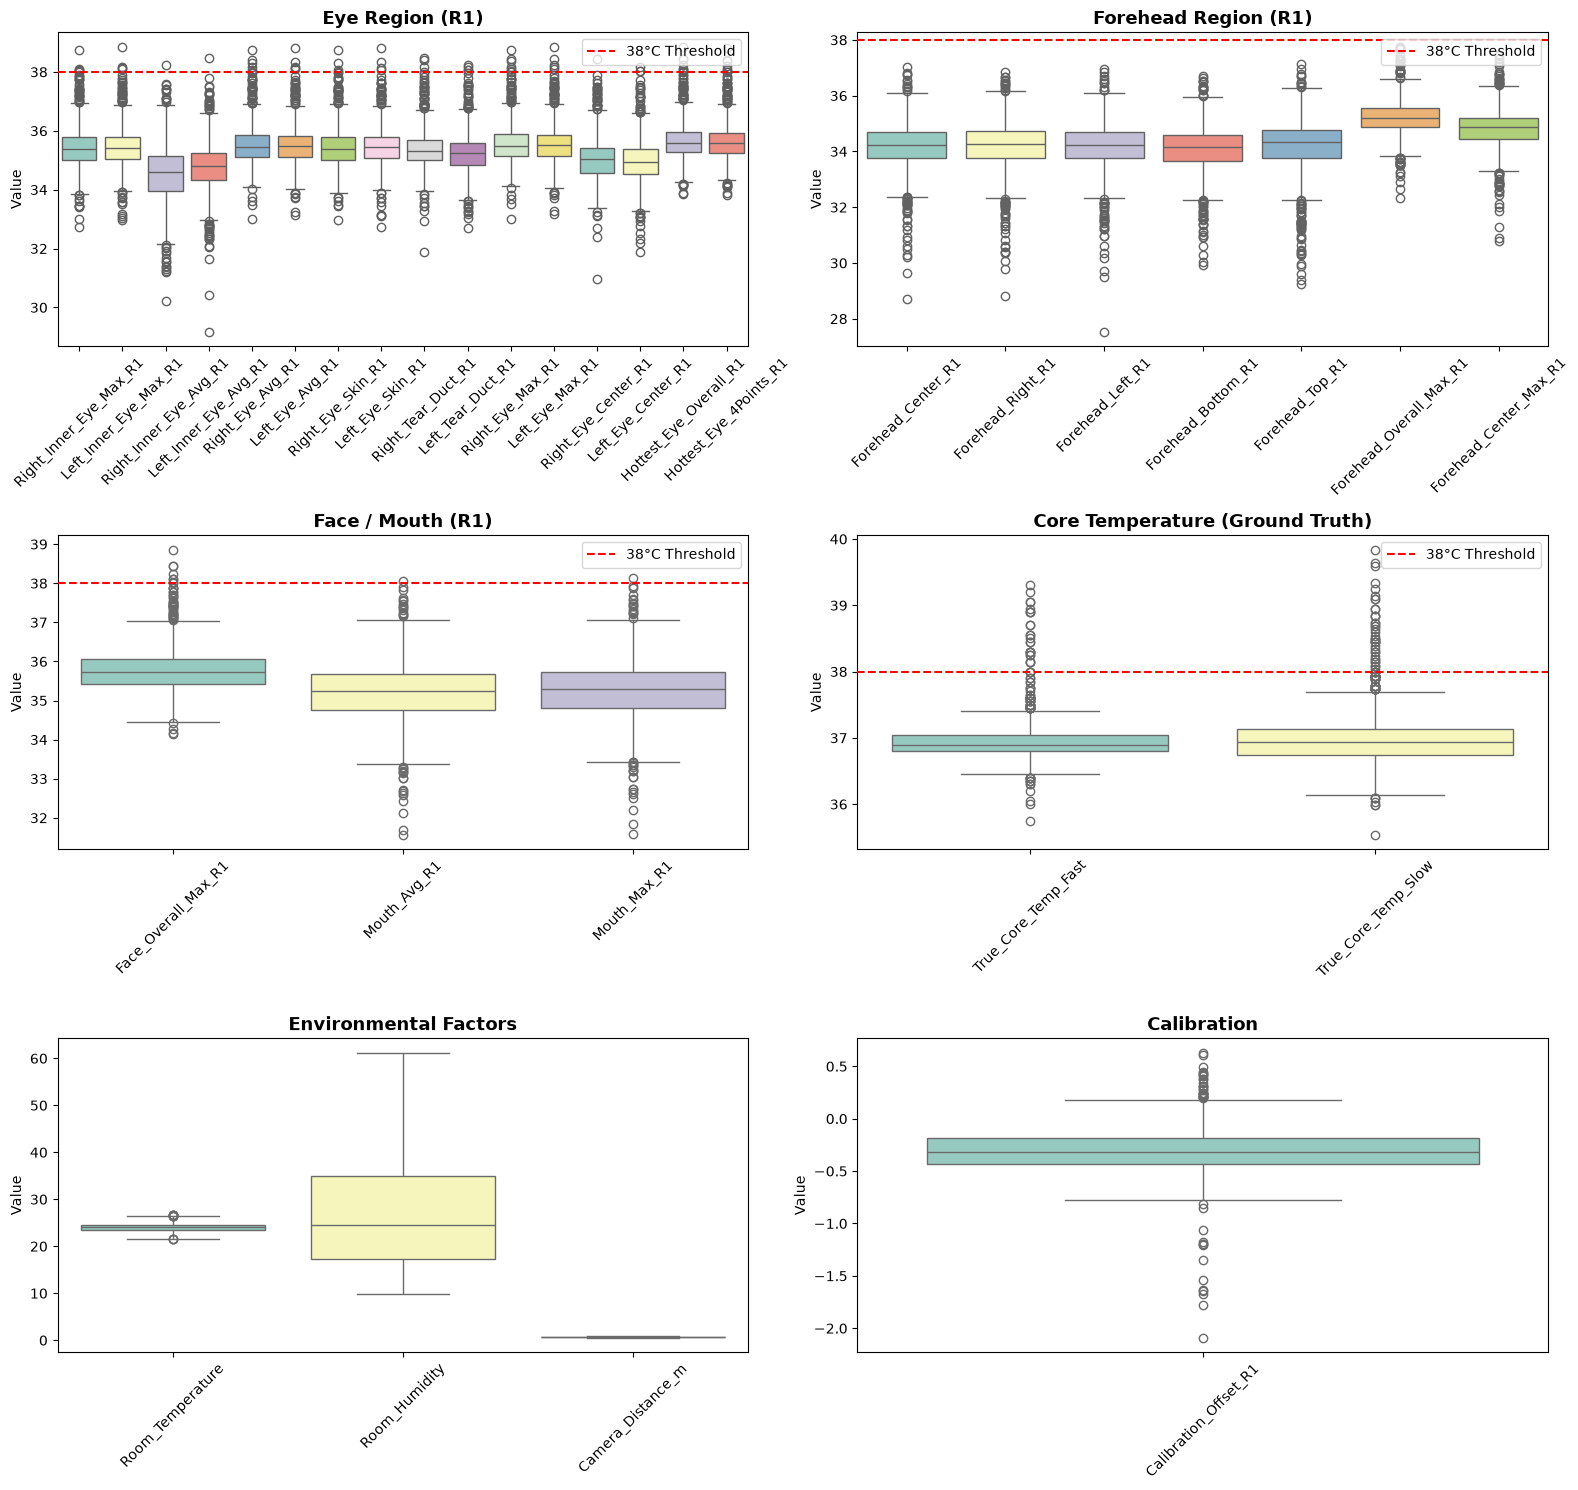

In [165]:
feature_groups = {
    "Eye Region (R1)": [
        'Right_Inner_Eye_Max_R1', 'Left_Inner_Eye_Max_R1',
        'Right_Inner_Eye_Avg_R1', 'Left_Inner_Eye_Avg_R1',
        'Right_Eye_Avg_R1', 'Left_Eye_Avg_R1',
        'Right_Eye_Skin_R1', 'Left_Eye_Skin_R1',
        'Right_Tear_Duct_R1', 'Left_Tear_Duct_R1',
        'Right_Eye_Max_R1', 'Left_Eye_Max_R1',
        'Right_Eye_Center_R1', 'Left_Eye_Center_R1',
        'Hottest_Eye_Overall_R1', 'Hottest_Eye_4Points_R1'
    ],
    "Forehead Region (R1)": [
        'Forehead_Center_R1', 'Forehead_Right_R1', 'Forehead_Left_R1',
        'Forehead_Bottom_R1', 'Forehead_Top_R1',
        'Forehead_Overall_Max_R1', 'Forehead_Center_Max_R1'
    ],
    "Face / Mouth (R1)": [
        'Face_Overall_Max_R1', 'Mouth_Avg_R1', 'Mouth_Max_R1'
    ],
    "Core Temperature (Ground Truth)": [
        'True_Core_Temp_Fast', 'True_Core_Temp_Slow'
    ],
    "Environmental Factors": [
        'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m'
    ],
    "Calibration": [
        'Calibration_Offset_R1'
    ]
}

n_groups = len(feature_groups)
n_cols = 2
n_rows = (n_groups + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for ax, (group_name, cols) in zip(axes, feature_groups.items()):
    melted = data[cols].melt(var_name="Feature", value_name="Value")
    sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
    if group_name not in ["Calibration", "Environmental Factors"]:
        ax.axhline(
            y=38.0, 
            color='red', 
            linestyle='--', 
            linewidth=1.5, 
            zorder=5, 
            label='38°C Threshold'
        )
        ax.legend(loc='upper right') 
    
    ax.set_title(group_name, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(feature_groups):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

a) Scatterplots

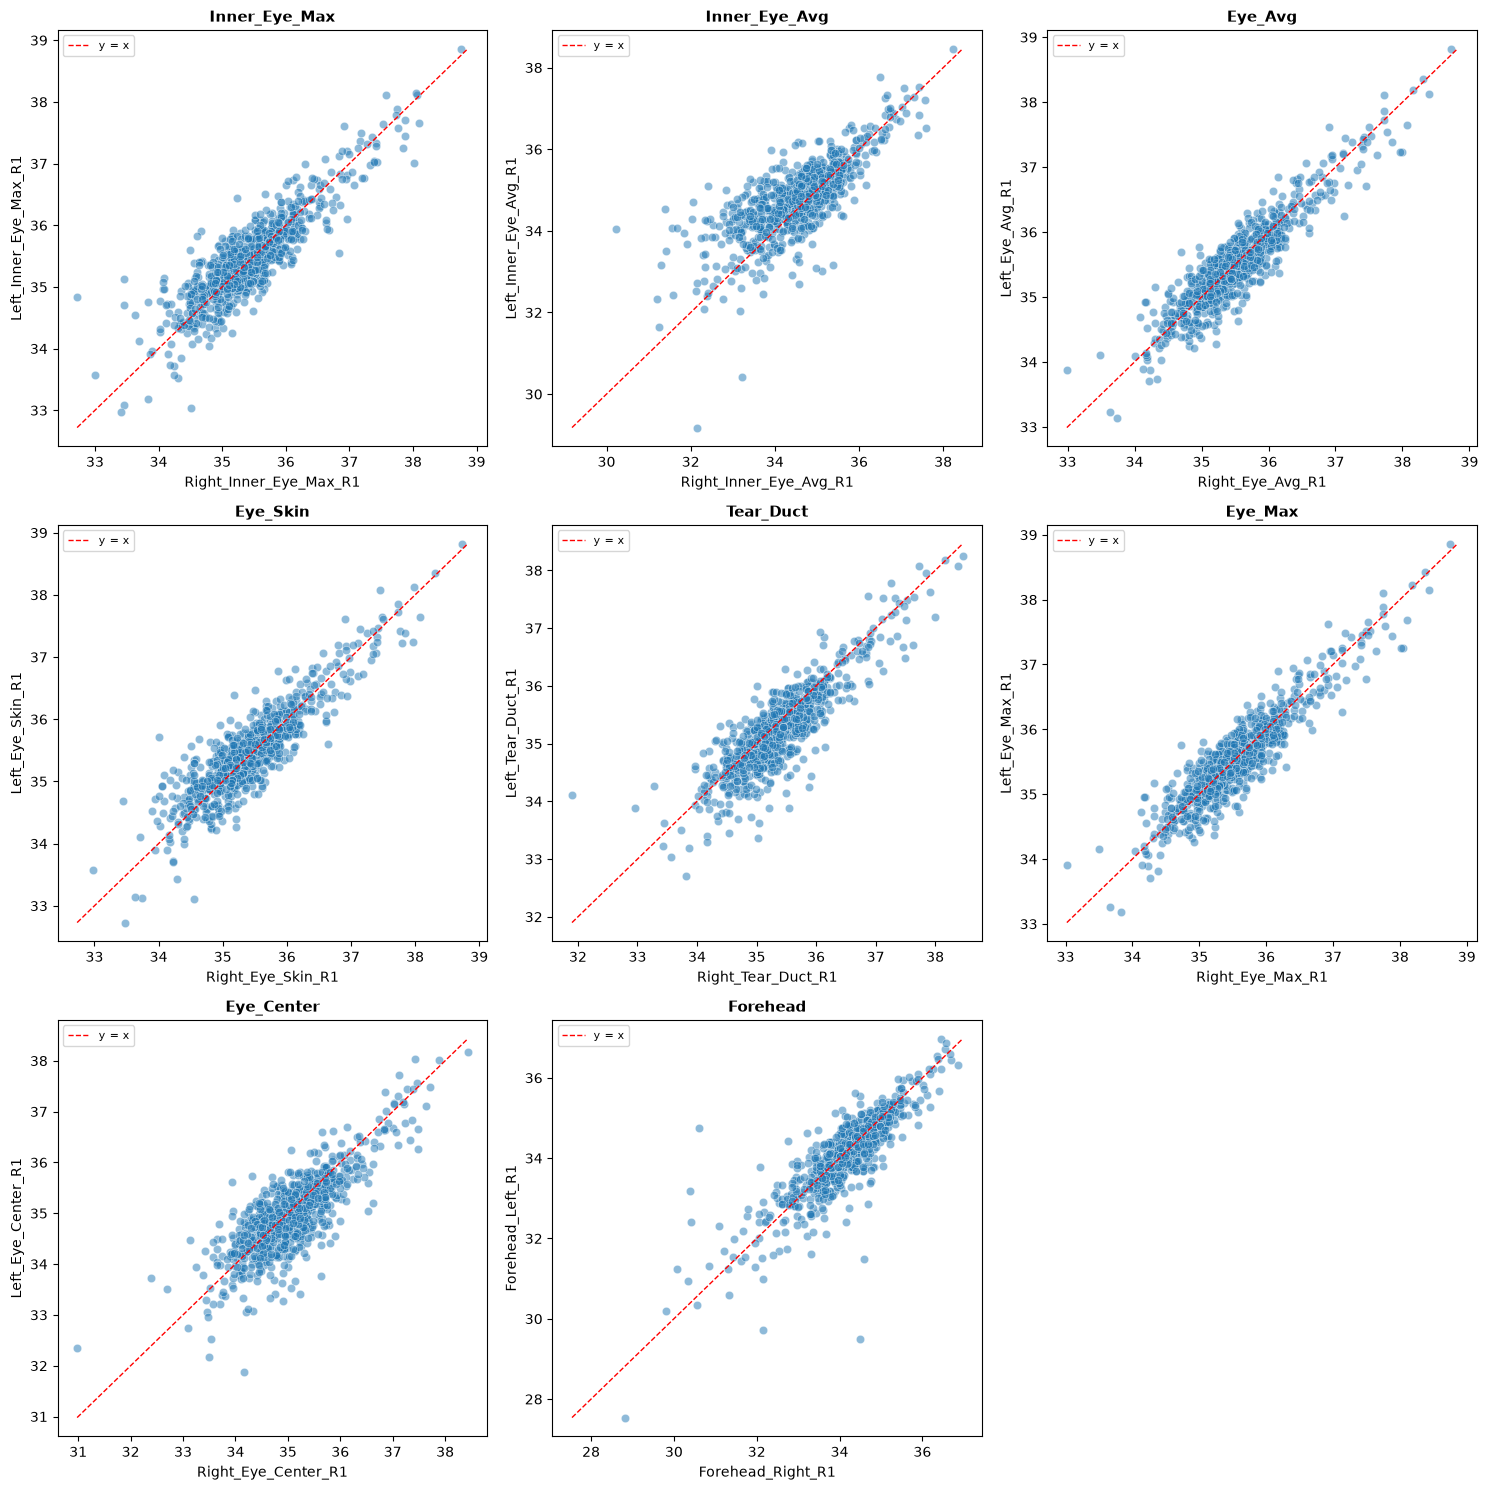

In [166]:
# Paired Right vs Left columns (symmetric measurements)
pairs = [
    ('Right_Inner_Eye_Max_R1', 'Left_Inner_Eye_Max_R1'),
    ('Right_Inner_Eye_Avg_R1', 'Left_Inner_Eye_Avg_R1'),
    ('Right_Eye_Avg_R1',       'Left_Eye_Avg_R1'),
    ('Right_Eye_Skin_R1',      'Left_Eye_Skin_R1'),
    ('Right_Tear_Duct_R1',     'Left_Tear_Duct_R1'),
    ('Right_Eye_Max_R1',       'Left_Eye_Max_R1'),
    ('Right_Eye_Center_R1',    'Left_Eye_Center_R1'),
    ('Forehead_Right_R1',      'Forehead_Left_R1'),
]

n_cols = 3
n_rows = -(-len(pairs) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for ax, (right_col, left_col) in zip(axes, pairs):
    sns.scatterplot(data=data, x=right_col, y=left_col, alpha=0.5, ax=ax)
    
    # y = x reference line to visualize perfect symmetry
    lims = [
        min(data[right_col].min(), data[left_col].min()),
        max(data[right_col].max(), data[left_col].max())
    ]
    ax.plot(lims, lims, 'r--', linewidth=1, label='y = x')
    
    ax.set_title(right_col.replace('Right_', '').replace('_R1', ''), fontsize=11, fontweight='bold')
    ax.set_xlabel(right_col)
    ax.set_ylabel(left_col)
    ax.legend(fontsize=8)

# Hide unused axes
for ax in axes[len(pairs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

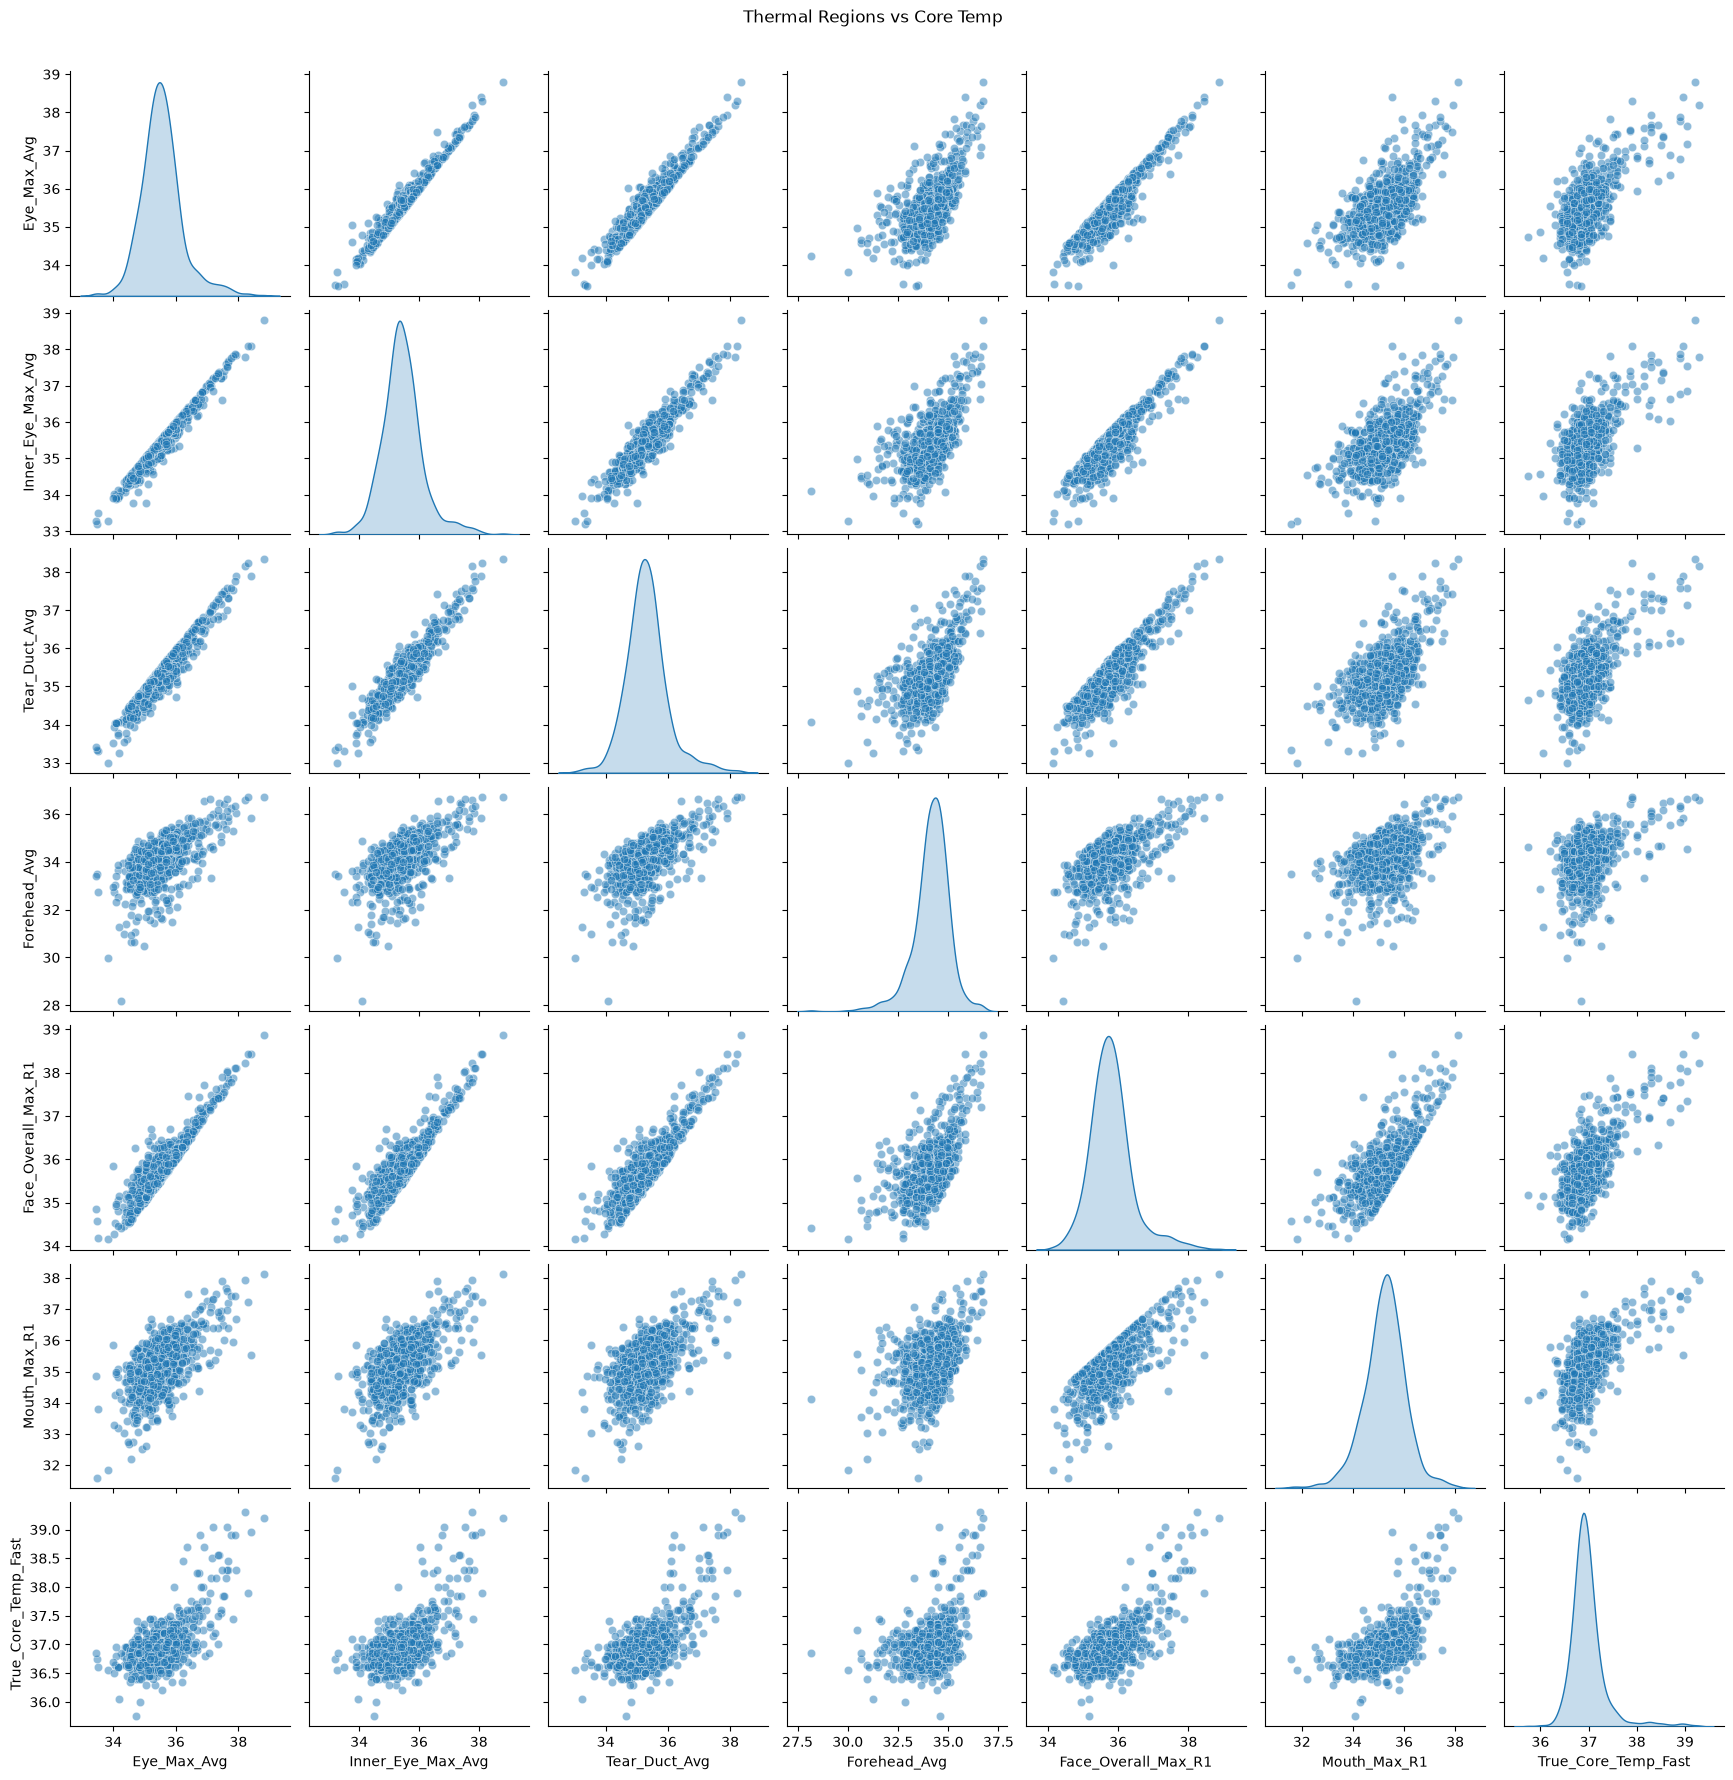

In [167]:
data_p = data.copy()

# Average left/right 
data_p['Eye_Max_Avg']       = data_p[['Right_Eye_Max_R1', 'Left_Eye_Max_R1']].mean(axis=1)
data_p['Inner_Eye_Max_Avg'] = data_p[['Right_Inner_Eye_Max_R1', 'Left_Inner_Eye_Max_R1']].mean(axis=1)
data_p['Tear_Duct_Avg']     = data_p[['Right_Tear_Duct_R1', 'Left_Tear_Duct_R1']].mean(axis=1)
data_p['Forehead_Avg']      = data_p[['Forehead_Right_R1', 'Forehead_Left_R1']].mean(axis=1)

cols = ['Eye_Max_Avg', 'Inner_Eye_Max_Avg', 'Tear_Duct_Avg', 'Forehead_Avg',
        'Face_Overall_Max_R1', 'Mouth_Max_R1', 'True_Core_Temp_Fast']

sns.pairplot(data_p[cols], kind='scatter', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Thermal Regions vs Core Temp", y=1.02)
plt.show()

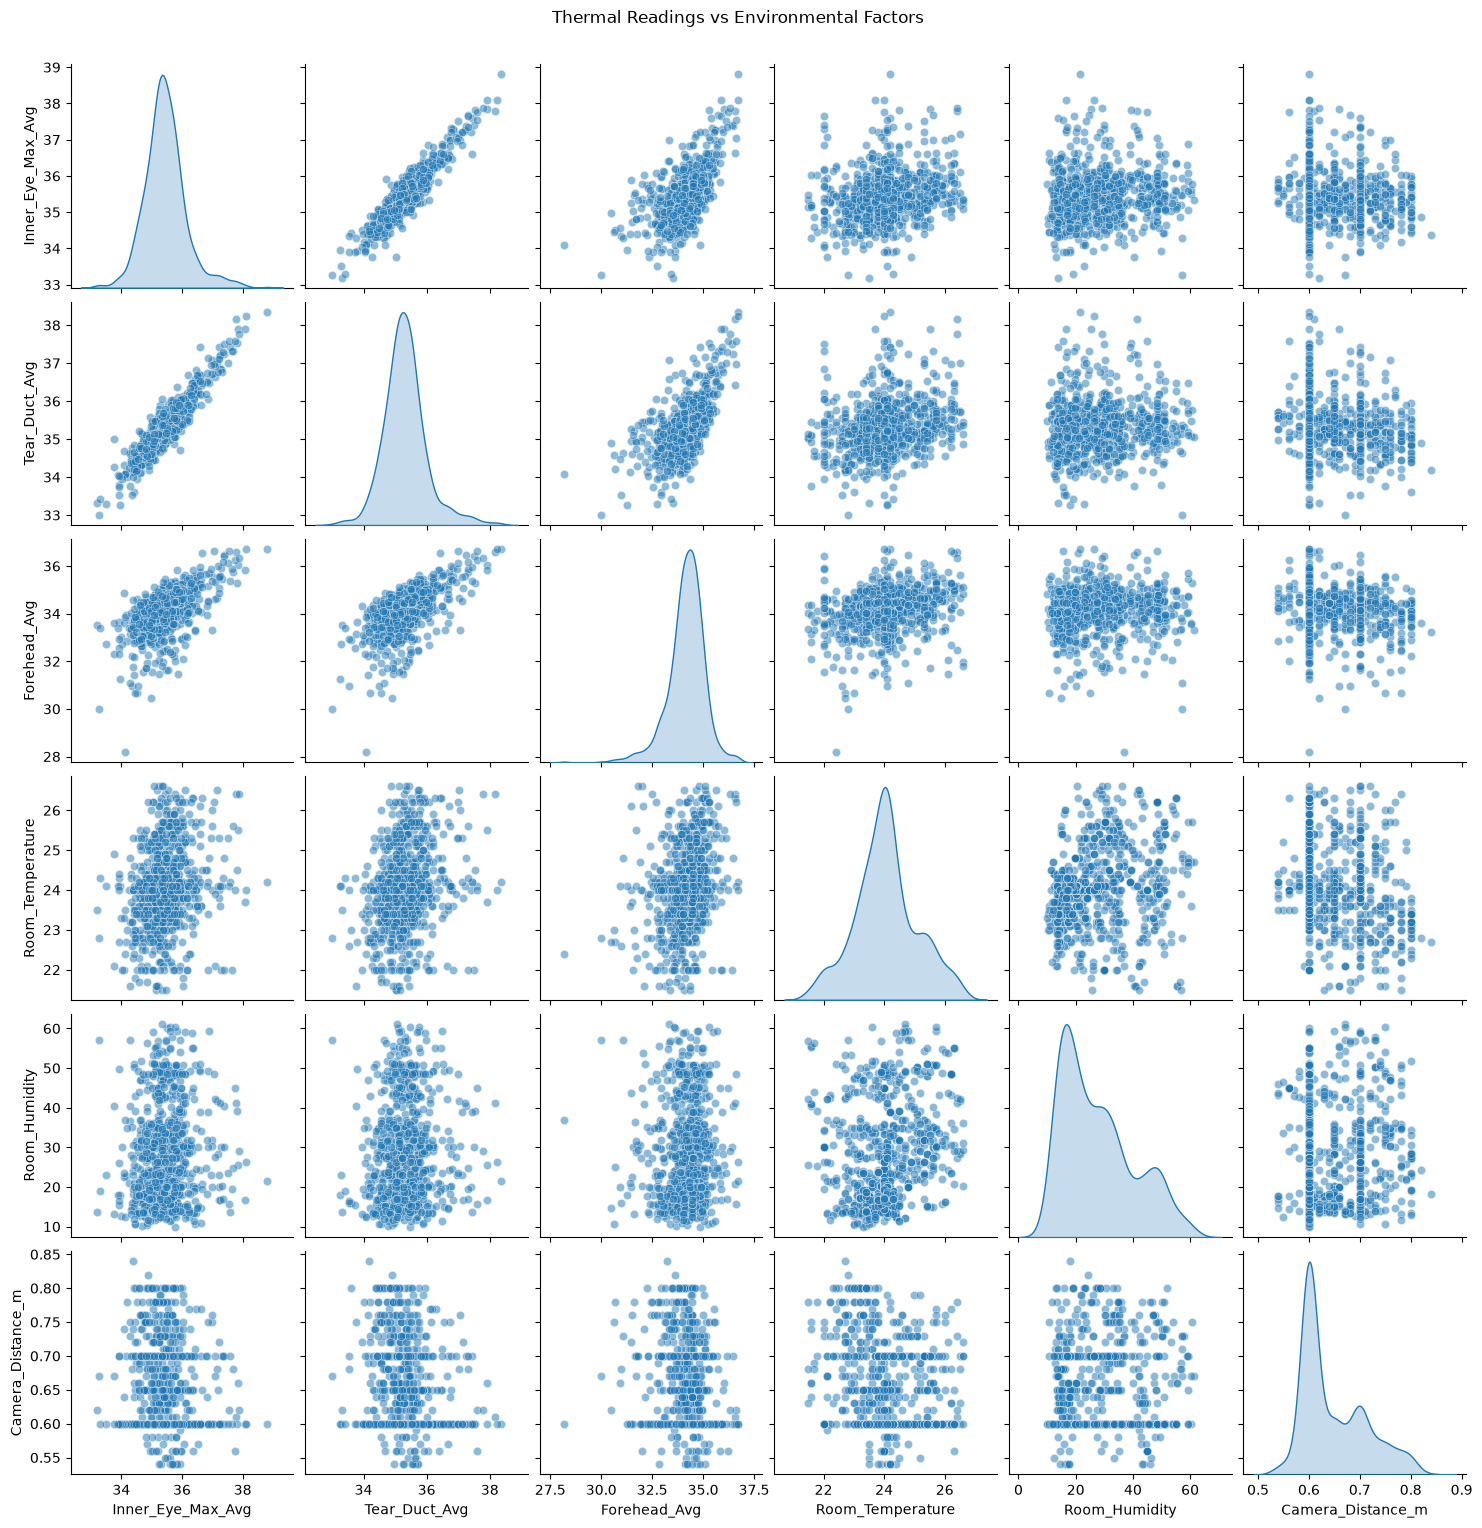

In [168]:
env_cols = ['Inner_Eye_Max_Avg', 'Tear_Duct_Avg', 'Forehead_Avg',
            'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m']

sns.pairplot(data_p[env_cols], kind='scatter', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Thermal Readings vs Environmental Factors", y=1.02)
plt.show()

b) Heatmap

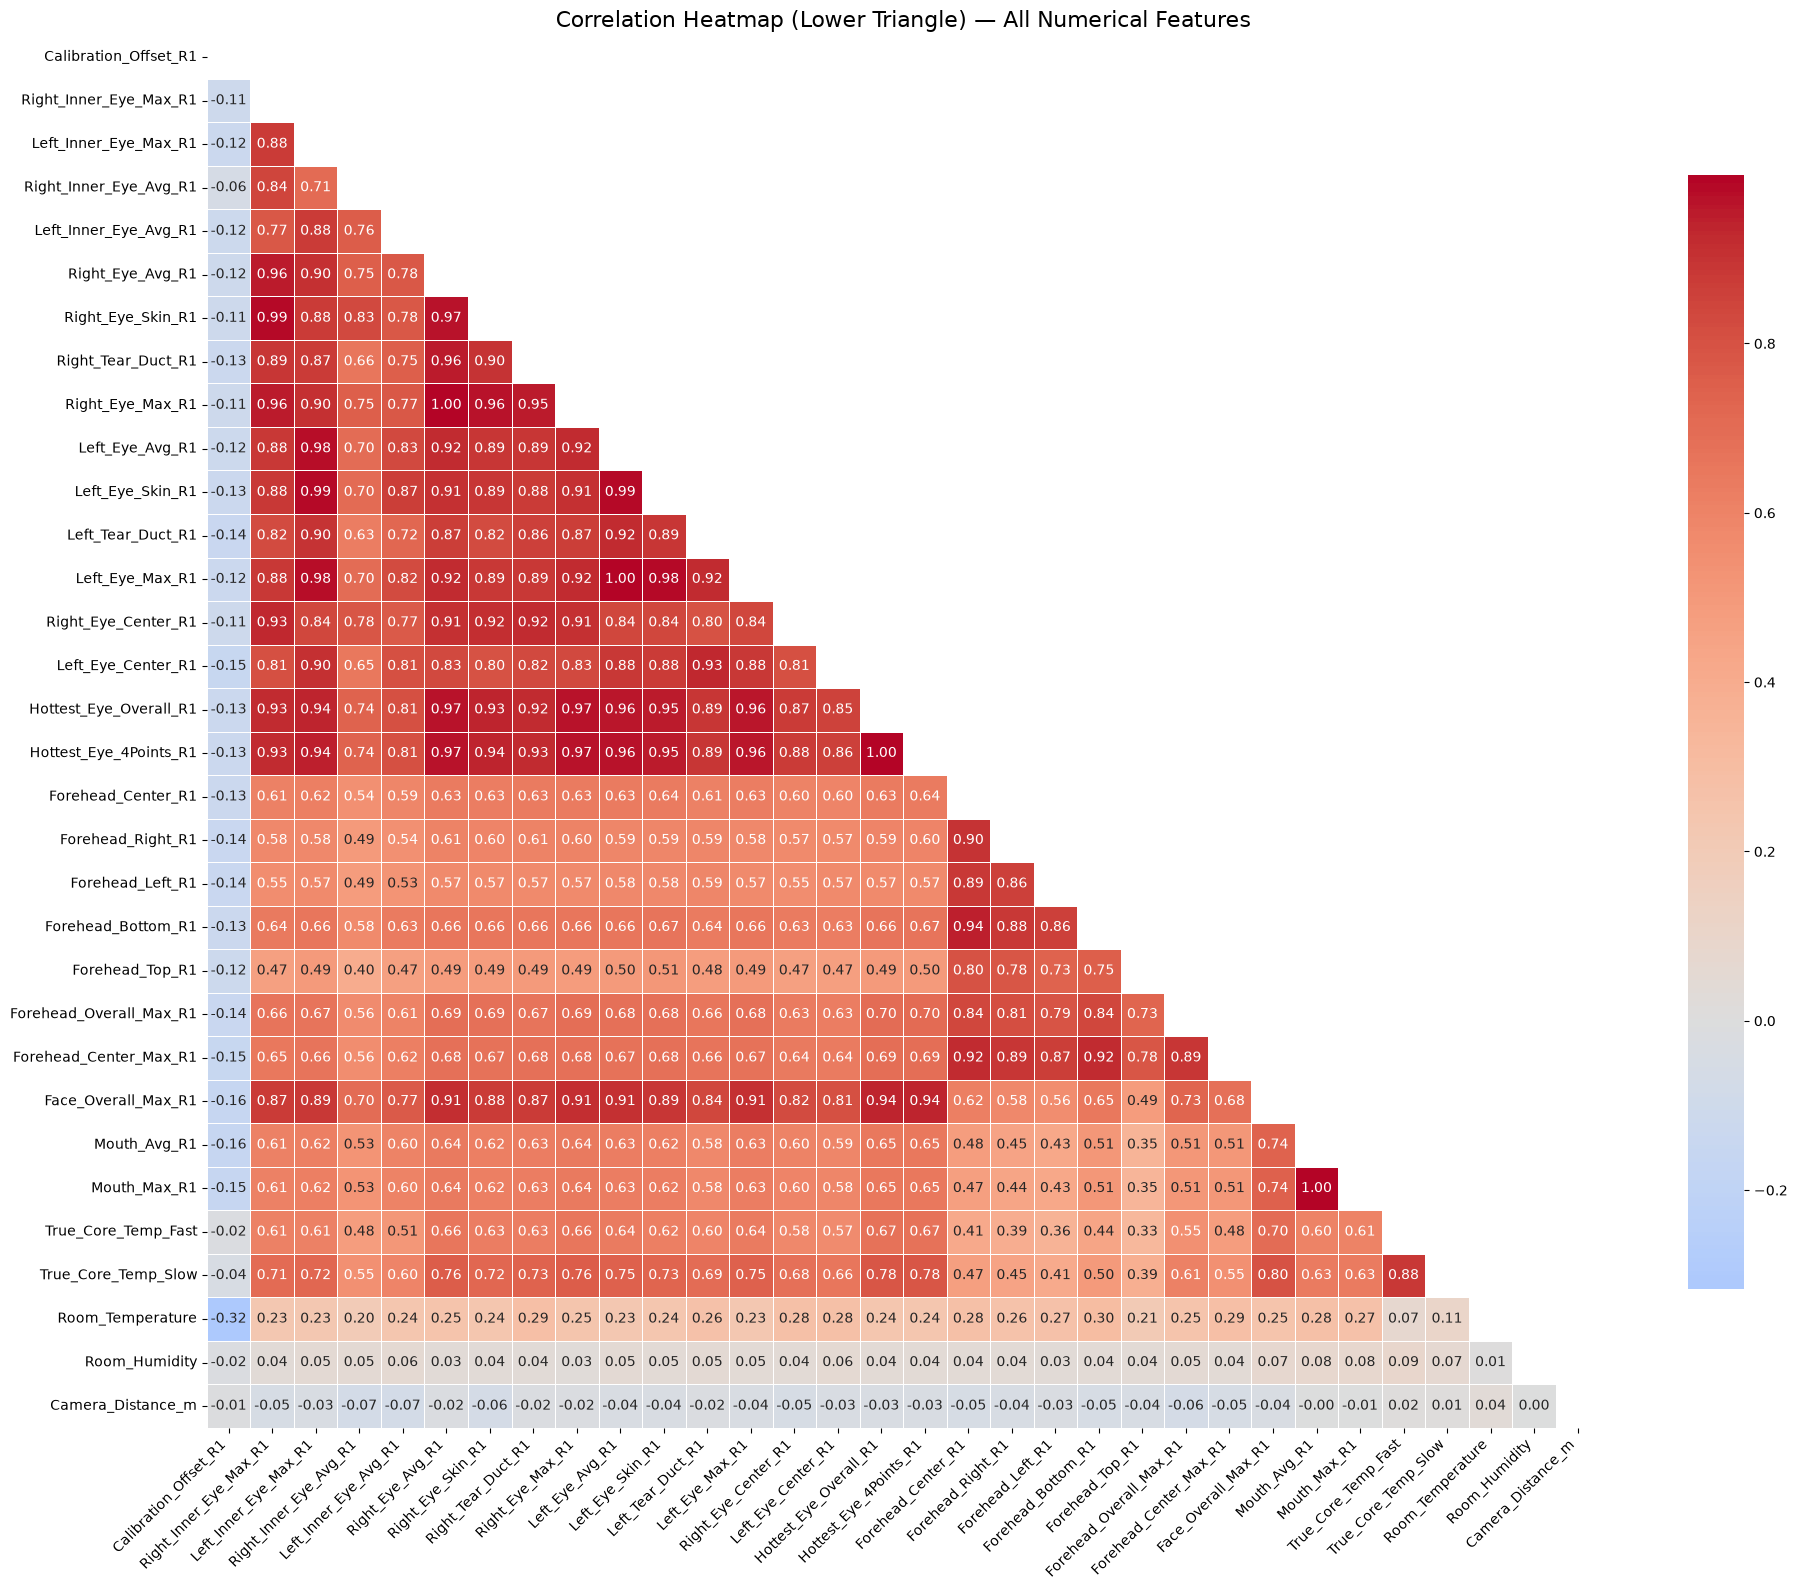

In [171]:
data = df[0]

numerical_features = [
    'Calibration_Offset_R1', 'Right_Inner_Eye_Max_R1', 'Left_Inner_Eye_Max_R1',
    'Right_Inner_Eye_Avg_R1', 'Left_Inner_Eye_Avg_R1', 'Right_Eye_Avg_R1',
    'Right_Eye_Skin_R1', 'Right_Tear_Duct_R1', 'Right_Eye_Max_R1',
    'Left_Eye_Avg_R1', 'Left_Eye_Skin_R1', 'Left_Tear_Duct_R1',
    'Left_Eye_Max_R1', 'Right_Eye_Center_R1', 'Left_Eye_Center_R1',
    'Hottest_Eye_Overall_R1', 'Hottest_Eye_4Points_R1', 'Forehead_Center_R1',
    'Forehead_Right_R1', 'Forehead_Left_R1', 'Forehead_Bottom_R1',
    'Forehead_Top_R1', 'Forehead_Overall_Max_R1', 'Forehead_Center_Max_R1',
    'Face_Overall_Max_R1', 'Mouth_Avg_R1', 'Mouth_Max_R1',
    'True_Core_Temp_Fast', 'True_Core_Temp_Slow', 'Room_Temperature',
    'Room_Humidity', 'Camera_Distance_m'
]

corr_matrix = data[numerical_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Correlation Heatmap (Lower Triangle) — All Numerical Features", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

drop features based on correlation values

In [172]:
data = df[0]

numerical_features = [
    'Calibration_Offset_R1', 'Right_Inner_Eye_Max_R1', 'Left_Inner_Eye_Max_R1',
    'Right_Inner_Eye_Avg_R1', 'Left_Inner_Eye_Avg_R1', 'Right_Eye_Avg_R1',
    'Right_Eye_Skin_R1', 'Right_Tear_Duct_R1', 'Right_Eye_Max_R1',
    'Left_Eye_Avg_R1', 'Left_Eye_Skin_R1', 'Left_Tear_Duct_R1',
    'Left_Eye_Max_R1', 'Right_Eye_Center_R1', 'Left_Eye_Center_R1',
    'Hottest_Eye_Overall_R1', 'Hottest_Eye_4Points_R1', 'Forehead_Center_R1',
    'Forehead_Right_R1', 'Forehead_Left_R1', 'Forehead_Bottom_R1',
    'Forehead_Top_R1', 'Forehead_Overall_Max_R1', 'Forehead_Center_Max_R1',
    'Face_Overall_Max_R1', 'Mouth_Avg_R1', 'Mouth_Max_R1',
    'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m'
]  

corr_matrix = data[numerical_features].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.9  

to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > threshold)]

print(f"Features to drop ({len(to_drop)}): {to_drop}")

data_reduced = data.drop(columns=to_drop)
print(f"\nRemaining features: {data_reduced.shape[1]}")

Features to drop (16): ['Right_Eye_Avg_R1', 'Right_Eye_Skin_R1', 'Right_Tear_Duct_R1', 'Right_Eye_Max_R1', 'Left_Eye_Avg_R1', 'Left_Eye_Skin_R1', 'Left_Tear_Duct_R1', 'Left_Eye_Max_R1', 'Right_Eye_Center_R1', 'Left_Eye_Center_R1', 'Hottest_Eye_Overall_R1', 'Hottest_Eye_4Points_R1', 'Forehead_Bottom_R1', 'Forehead_Center_Max_R1', 'Face_Overall_Max_R1', 'Mouth_Max_R1']

Remaining features: 23


6. Now, do the above and plot it as a subplot where each subplot corresponds to a trial. We will create a 2x2 subplot.

### Data Cleaning

7. Based on the above, we shall now clean the datasets of outliers.

8. Do imputation for missing data

9. Redo the above plots